/tmp/ipykernel_62876/2394370142.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"future_return_{n}"] = df["mid_price"].shift(-n) - df["mid_price"]
/tmp/ipykernel_62876/2394370142.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"future_return_{n}"] = df["mid_price"].shift(-n) - df["mid_price"]
/tmp/ipykernel_62876/2394370142.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

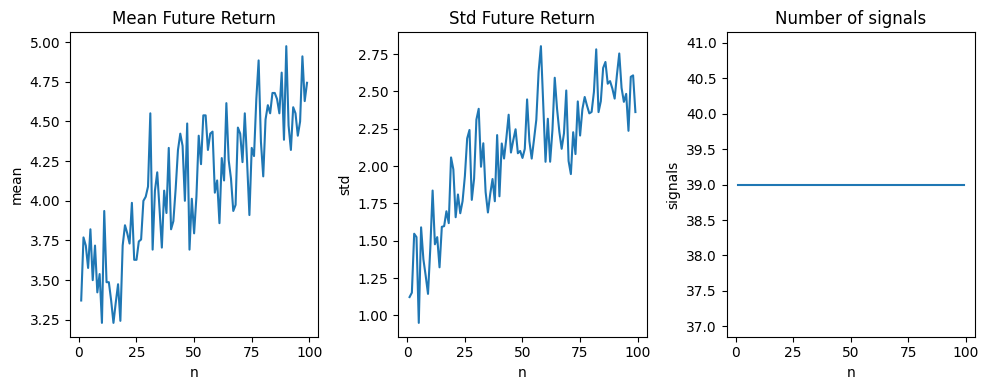

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load both days
df1 = pd.read_csv("prices_round_2_day_-1.csv", sep=";")
df2 = pd.read_csv("prices_round_2_day_0.csv", sep=";")

# choose product
product = "ASH_COATED_OSMIUM"
df1 = df1[df1["product"] == product].copy()
df2 = df2[df2["product"] == product].copy()

# keep rows where best bid/ask exist
df1 = df1[df1["bid_price_1"].notna() & df1["ask_price_1"].notna()].copy()
df2 = df2[df2["bid_price_1"].notna() & df2["ask_price_1"].notna()].copy()

# recompute mid price
df1["mid_price"] = (df1["bid_price_1"] + df1["ask_price_1"]) / 2
df2["mid_price"] = (df2["bid_price_1"] + df2["ask_price_1"]) / 2

# shift timestamps of day 0 so the series is continuous
offset = df1["timestamp"].max() + 100
df2["timestamp"] += offset

# combine
# df = df1
df = pd.concat([df1, df2], ignore_index=True)
df = df.sort_values("timestamp").reset_index(drop=True)
df = df[df['product'] == "ASH_COATED_OSMIUM"]

# fill missing depth volumes with 0
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]
df[volume_cols] = df[volume_cols].fillna(0)

# total bid / ask volume across top 3 levels
df["total_bid_vol"] = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].sum(axis=1)
df["total_ask_vol"] = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].sum(axis=1)

# imbalance
denom = df["total_bid_vol"] + df["total_ask_vol"]
df["imbalance"] = np.where(
    denom > 0,
    (df["total_bid_vol"] - df["total_ask_vol"]) / denom,
    np.nan
)

means = np.array([])
stds = np.array([])
n_array = np.array([])
nums_array = np.array([])

for n in range(1, 100):
    # future return: n-step mid price change
    df[f"future_return_{n}"] = df["mid_price"].shift(-n) - df["mid_price"]

    # keep only valid rows
    test_df = df[["timestamp", "mid_price", "imbalance", f"future_return_{n}"]].dropna().copy()
    test_df = test_df[abs(test_df[f'imbalance']) >= 0.7]

    mean = abs(test_df[f'future_return_{n}']).mean()
    std = abs(test_df[f'future_return_{n}']).std()
    n_array = np.append(n_array, [n])
    means = np.append(means, [mean])
    stds = np.append(stds, [std])
    nums_array = np.append(nums_array, [len(test_df)])

    # correlation
    corr_val = test_df["imbalance"].corr(test_df[f"future_return_{n}"])

    # print(f"Correlation between imbalance and {n}-step future return:", corr_val)

    # optional: scatter plot
    # plt.figure(figsize=(8, 5))
    # plt.scatter(test_df["imbalance"], test_df[f"future_return_{n}"], alpha=0.3)
    # plt.axhline(0, linestyle="--")
    # plt.axvline(0, linestyle="--")
    # plt.title(f"Imbalance vs Future Return ({product}, {n})")
    # plt.xlabel("Imbalance")
    # plt.ylabel("Future Return")
    # plt.show()

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].plot(n_array, means)
ax[0].set_title("Mean Future Return")
ax[0].set_xlabel("n")
ax[0].set_ylabel("mean")
ax[1].plot(n_array, stds)
ax[1].set_title("Std Future Return")
ax[1].set_xlabel("n")
ax[1].set_ylabel("std")
ax[2].plot(n_array, nums_array)
ax[2].set_title("Number of signals")
ax[2].set_xlabel("n")
ax[2].set_ylabel("signals")
plt.tight_layout()
# plt.plot(n_array, means)
plt.show()

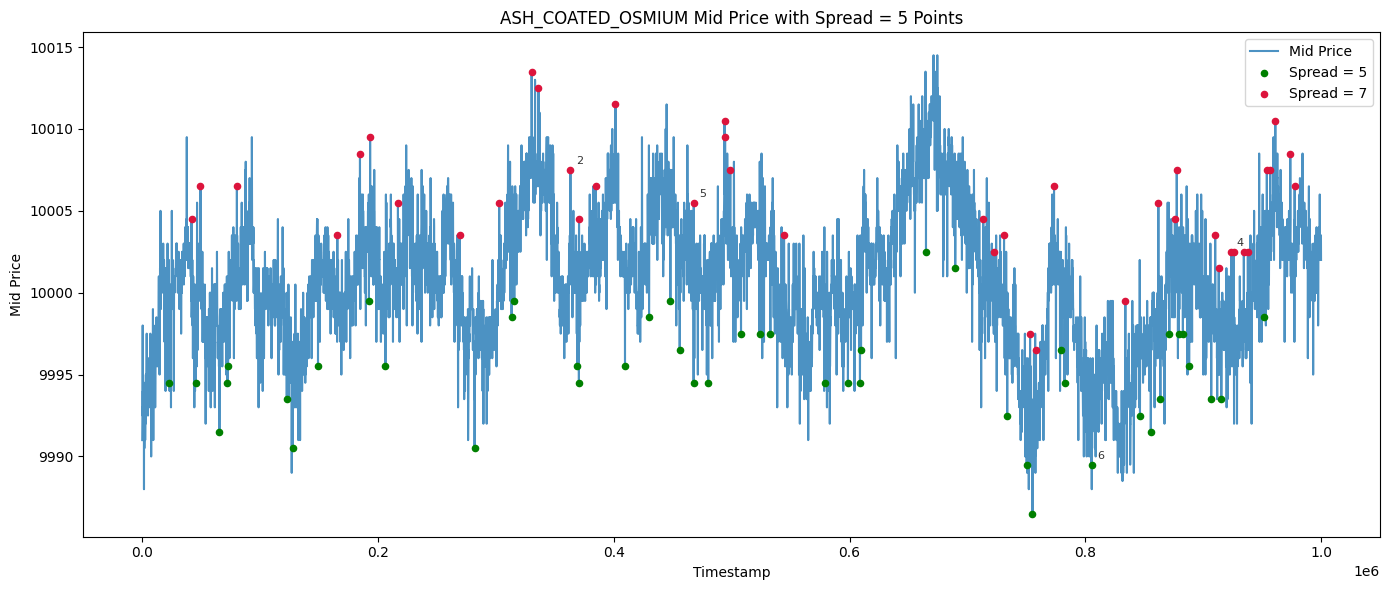

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load both days
df1 = pd.read_csv("prices_round_2_day_-1.csv", sep=";")
df2 = pd.read_csv("prices_round_2_day_0.csv", sep=";")
df1_trades = pd.read_csv("trades_round_2_day_-1.csv", sep=';')
df2_trades = pd.read_csv("trades_round_2_day_0.csv", sep=';')

# choose product
product = "ASH_COATED_OSMIUM"
df1 = df1[df1["product"] == product].copy()
df2 = df2[df2["product"] == product].copy()

# keep rows where best bid/ask exist
df1 = df1[df1["bid_price_1"].notna() & df1["ask_price_1"].notna()].copy()
df2 = df2[df2["bid_price_1"].notna() & df2["ask_price_1"].notna()].copy()

# recompute mid price
df1["mid_price"] = (df1["bid_price_1"] + df1["ask_price_1"]) / 2
df2["mid_price"] = (df2["bid_price_1"] + df2["ask_price_1"]) / 2

# shift timestamps of day 0 so the series is continuous
offset = df1["timestamp"].max() + 100
df2["timestamp"] += offset
df2_trades["timestamp"] += offset

# combine
df = df1
df_trades = df1_trades
# df = pd.concat([df1, df2], ignore_index=True)
# df = df.sort_values("timestamp").reset_index(drop=True)
# df_trades = pd.concat([df1_trades, df2_trades], ignore_index=True)
# df_trades = df_trades.sort_values("timestamp").reset_index(drop=True)


df = df[df['product'] == "ASH_COATED_OSMIUM"]
df_trades = df_trades[df_trades['symbol'] == "ASH_COATED_OSMIUM"]

# fill missing depth volumes with 0
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]
df[volume_cols] = df[volume_cols].fillna(0)

# total bid / ask volume across top 3 levels
df["total_bid_vol"] = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].sum(axis=1)
df["total_ask_vol"] = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].sum(axis=1)

# spread
denom = df["total_bid_vol"] + df["total_ask_vol"]
df["spread"] = np.where(
    denom > 0,
    (df["ask_price_1"] - df["bid_price_1"]),
    np.nan
)

spread_points_5 = df[df["spread"] == 5].copy()
spread_points_7 = df[df["spread"] == 7].copy()
trade_qty_by_ts = df_trades.groupby("timestamp")["quantity"].sum()


In [24]:
trade_qty_by_ts.head()

timestamp
0       6
3600    3
4200    2
9100    4
9600    6
Name: quantity, dtype: int64

None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
6
None
None
None
None
None
None
None
None
None
None


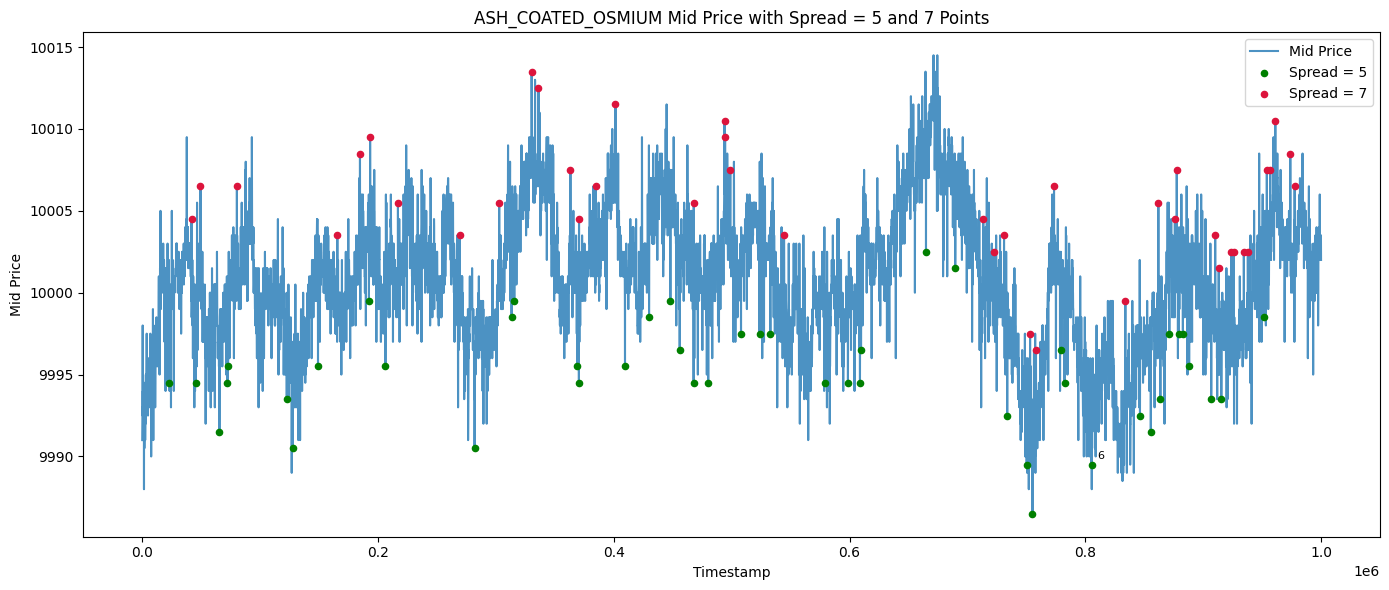

In [46]:



plt.figure(figsize=(14, 6))
plt.plot(df["timestamp"], df["mid_price"], label="Mid Price", alpha=0.8)
plt.scatter(
    spread_points_5["timestamp"],
    spread_points_5["mid_price"],
    color="green",
    s=20,
    label="Spread = 5",
    zorder=3,
)

plt.scatter(
    spread_points_7["timestamp"],
    spread_points_7["mid_price"],
    color="crimson",
    s=20,
    label="Spread = 7",
    zorder=3,
)

for row in spread_points_5.iterrows():
    timestamp = row[1]['timestamp']
    traded_qty = trade_qty_by_ts.get(timestamp)
    print(traded_qty)
    if not traded_qty: 
        continue
    plt.annotate(
        f"{int(traded_qty)}",
        (timestamp, row[1]["mid_price"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=1,
    )


# for point_set in (spread_points_5, spread_points_7):
#     for _, row in point_set.iterrows():
#         traded_qty = trade_qty_by_ts.get(row["timestamp"])
#         if pd.notna(traded_qty):
#             plt.annotate(
#                 f"{int(traded_qty)}",
#                 (row["timestamp"], row["mid_price"]),
#                 textcoords="offset points",
#                 xytext=(4, 4),
#                 fontsize=8,
#                 alpha=1,
#             )
plt.title(f"{product} Mid Price with Spread = 5 and 7 Points")
plt.xlabel("Timestamp")
plt.ylabel("Mid Price")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load both days
df1 = pd.read_csv("prices_round_2_day_-1.csv", sep=";")
df2 = pd.read_csv("prices_round_2_day_0.csv", sep=";")
df1_trades = pd.read_csv("trades_round_2_day_-1.csv", sep=';')
df2_trades = pd.read_csv("trades_round_2_day_0.csv", sep=';')

# choose product
product = "ASH_COATED_OSMIUM"
df1 = df1[df1["product"] == product].copy()
df2 = df2[df2["product"] == product].copy()

# keep rows where best bid/ask exist
df1 = df1[df1["bid_price_1"].notna() & df1["ask_price_1"].notna()].copy()
df2 = df2[df2["bid_price_1"].notna() & df2["ask_price_1"].notna()].copy()

# recompute mid price
df1["mid_price"] = (df1["bid_price_1"] + df1["ask_price_1"]) / 2
df2["mid_price"] = (df2["bid_price_1"] + df2["ask_price_1"]) / 2

# shift timestamps of day 0 so the series is continuous
offset = df1["timestamp"].max() + 100
df2["timestamp"] += offset
df2_trades["timestamp"] += offset

# combine
df = df1
df_trades = df1_trades
# df = pd.concat([df1, df2], ignore_index=True)
# df = df.sort_values("timestamp").reset_index(drop=True)
# df_trades = pd.concat([df1_trades, df2_trades], ignore_index=True)
# df_trades = df_trades.sort_values("timestamp").reset_index(drop=True)


df = df[df['product'] == "ASH_COATED_OSMIUM"]
df_trades = df_trades[df_trades['symbol'] == "ASH_COATED_OSMIUM"]

# fill missing depth volumes with 0
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]
df[volume_cols] = df[volume_cols].fillna(0)

# total bid / ask volume across top 3 levels
df["total_bid_vol"] = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].sum(axis=1)
df["total_ask_vol"] = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].sum(axis=1)

# spread
denom = df["total_bid_vol"] + df["total_ask_vol"]
df["spread"] = np.where(
    denom > 0,
    (df["ask_price_1"] - df["bid_price_1"]),
    np.nan
)

spread_points_5 = df[df["spread"] == 5].copy()
spread_points_7 = df[df["spread"] == 7].copy()
trade_qty_by_ts = df_trades.groupby("timestamp")["quantity"].sum()



plt.figure(figsize=(14, 6))
plt.plot(df["timestamp"], df["mid_price"], label="Mid Price", alpha=0.8)
plt.scatter(
    spread_points_5["timestamp"],
    spread_points_5["mid_price"],
    color="green",
    s=20,
    label="Spread = 5",
    zorder=3,
)

plt.scatter(
    spread_points_7["timestamp"],
    spread_points_7["mid_price"],
    color="crimson",
    s=20,
    label="Spread = 7",
    zorder=3,
)

for point_set in (spread_points_5, spread_points_7):
    for _, row in point_set.iterrows():
        traded_qty = trade_qty_by_ts.get(row["timestamp"])
        if pd.notna(traded_qty):
            plt.annotate(
                f"{int(traded_qty)}",
                (row["timestamp"], row["mid_price"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=8,
                alpha=0.8,
            )
plt.title(f"{product} Mid Price with Spread = 5 Points")
plt.xlabel("Timestamp")
plt.ylabel("Mid Price")
plt.legend()
plt.tight_layout()
plt.show()

/home/ora/Desktop/prosperity_alc/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ora/Desktop/prosperity_alc/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ora/Desktop/prosperity_alc/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ora/Desktop/prosperity_alc/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ora/Desktop/prosperity_alc/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ora/Desktop/prosperity_alc/.venv/lib/python3.10/site-packages/numpy/lib/_function_ba

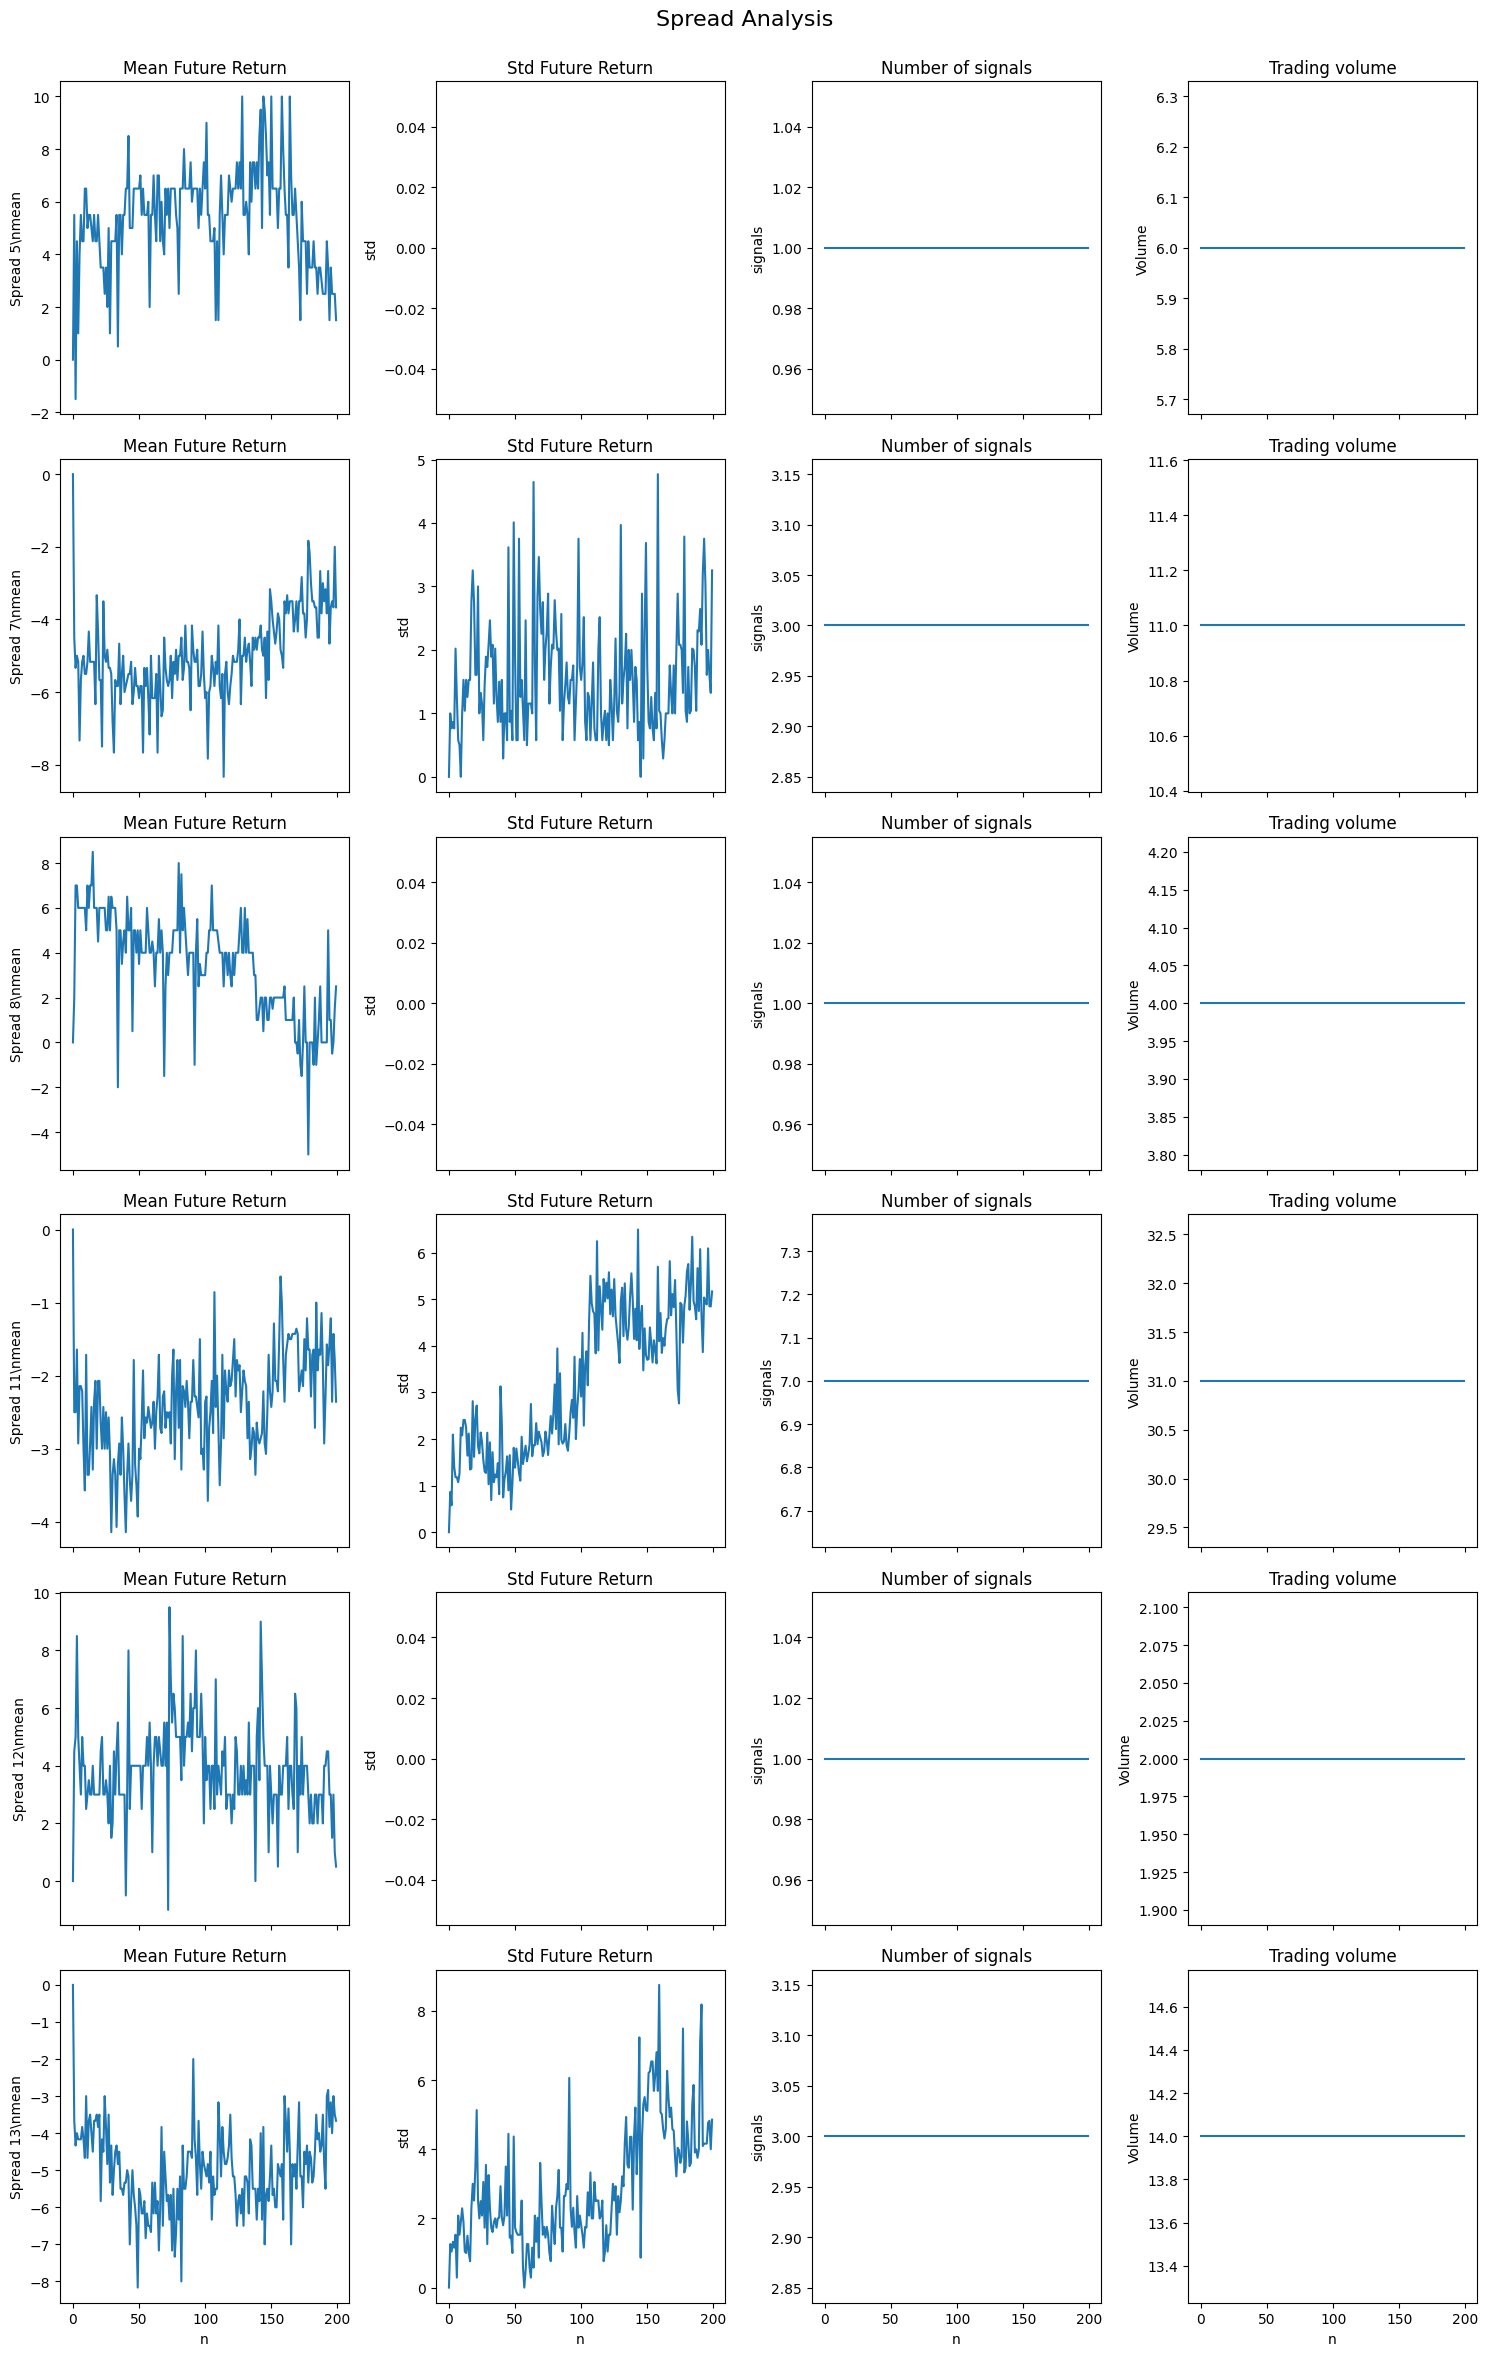

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load both days
df1 = pd.read_csv("prices_round_2_day_-1.csv", sep=";")
df2 = pd.read_csv("prices_round_2_day_0.csv", sep=";")
df1_trades = pd.read_csv("trades_round_2_day_-1.csv", sep=';')
df2_trades = pd.read_csv("trades_round_2_day_0.csv", sep=';')

# choose product
product = "ASH_COATED_OSMIUM"
df1 = df1[df1["product"] == product].copy()
df2 = df2[df2["product"] == product].copy()

# keep rows where best bid/ask exist
df1 = df1[df1["bid_price_1"].notna() & df1["ask_price_1"].notna()].copy()
df2 = df2[df2["bid_price_1"].notna() & df2["ask_price_1"].notna()].copy()

# recompute mid price
df1["mid_price"] = (df1["bid_price_1"] + df1["ask_price_1"]) / 2
df2["mid_price"] = (df2["bid_price_1"] + df2["ask_price_1"]) / 2

# shift timestamps of day 0 so the series is continuous
offset = df1["timestamp"].max() + 100
df2["timestamp"] += offset
df2_trades["timestamp"] += offset

# combine
df = df1
df_trades = df1_trades
# df = pd.concat([df1, df2], ignore_index=True)
# df = df.sort_values("timestamp").reset_index(drop=True)
# df_trades = pd.concat([df1_trades, df2_trades], ignore_index=True)
# df_trades = df_trades.sort_values("timestamp").reset_index(drop=True)


df = df[df['product'] == "ASH_COATED_OSMIUM"]
df_trades = df_trades[df_trades['symbol'] == "ASH_COATED_OSMIUM"]

# fill missing depth volumes with 0
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]
df[volume_cols] = df[volume_cols].fillna(0)

# total bid / ask volume across top 3 levels
df["total_bid_vol"] = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].sum(axis=1)
df["total_ask_vol"] = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].sum(axis=1)

# spread
denom = df["total_bid_vol"] + df["total_ask_vol"]
df["spread"] = np.where(
    denom > 0,
    (df["ask_price_1"] - df["bid_price_1"]),
    np.nan
)

spreads = [5, 7, 8, 11, 12, 13]
fig, axes = plt.subplots(len(spreads), 4, figsize=(15, 4 * len(spreads)), sharex=True)

for row_idx, spread in enumerate(spreads):

    means = np.array([])
    stds = np.array([])
    signals = np.array([])
    n_array = np.array([])
    trading_volumes = np.array([])

    for n in range(200):
        # future return: next-step mid price change
        df["future_return"] = df["mid_price"].shift(-n) - df["mid_price"]

        # keep only valid rows
        test_df = df[["timestamp", "mid_price", "spread", "future_return"]].dropna().copy()
        test_df = test_df[test_df['spread'] == spread]

        filtered_test_df = test_df[test_df["timestamp"].isin(df_trades["timestamp"].tolist())]
        # print("Legit signals:", len(filtered_test_df))
        # for ts in filtered_test_df['timestamp']:
        #     matching_qty = df_trades.loc[df_trades['timestamp'] == ts, 'quantity']
        #     if not matching_qty.empty:
        #         print(matching_qty.iloc[0])

        means = np.append(means, [filtered_test_df['future_return'].mean()])
        stds = np.append(stds, [filtered_test_df['future_return'].std()])
        signals = np.append(signals, [len(filtered_test_df)])
        n_array = np.append(n_array, [n])
        volume = 0

        for ts in filtered_test_df['timestamp']:
            matching_qty = df_trades.loc[df_trades['timestamp'] == ts, 'quantity']
            if not matching_qty.empty:
                volume += matching_qty.iloc[0]
            else:
                volume += matching_qty

        trading_volumes = np.append(trading_volumes, [volume])
        


        # correlation
        corr_val = test_df["spread"].corr(test_df["future_return"])

        # print("Correlation between spread and future return:", corr_val)

        # optional: scatter plot
        # plt.figure(figsize=(8, 5))
        # plt.scatter(test_df["spread"], test_df["future_return"], alpha=0.3)
        # plt.axhline(0, linestyle="--")
        # plt.axvline(0, linestyle="--")
        # plt.title(f"Spread vs Future Return ({product})")
        # plt.xlabel("Spread")
        # plt.ylabel("Future Return")
        # plt.show()
    ax = axes[row_idx]
    ax[0].plot(n_array, means)
    ax[0].set_title("Mean Future Return")
    ax[0].set_ylabel(f"Spread {spread}\\nmean")
    ax[1].plot(n_array, stds)
    ax[1].set_title("Std Future Return")
    ax[1].set_ylabel("std")
    ax[2].plot(n_array, signals)
    ax[2].set_title("Number of signals")
    ax[2].set_ylabel("signals")
    ax[3].plot(n_array, trading_volumes)
    ax[3].set_title("Trading volume")
    ax[3].set_ylabel("Volume")

for ax in axes[-1]:
    ax.set_xlabel("n")

fig.suptitle("Spread Analysis", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()